In [ ]:
# ============================================================
# Cell 1: Mount Google Drive and create CPI project folder
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import os
import sys
import shutil
import json
import subprocess
import textwrap
import pandas as pd
import numpy as np

PROJECT_ROOT = Path("/content/drive/MyDrive/UM_WQF7023")
CPI_ROOT = PROJECT_ROOT / "CPI_3D_GNN_Exploration"
REPO_ROOT = CPI_ROOT / "CPI_prediction"
OUTPUT_ROOT = CPI_ROOT / "outputs"

for folder in [PROJECT_ROOT, CPI_ROOT, OUTPUT_ROOT]:
    folder.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("CPI_ROOT:", CPI_ROOT)
print("REPO_ROOT:", REPO_ROOT)
print("OUTPUT_ROOT:", OUTPUT_ROOT)

Mounted at /content/drive
PROJECT_ROOT: /content/drive/MyDrive/UM_WQF7023
CPI_ROOT: /content/drive/MyDrive/UM_WQF7023/CPI_3D_GNN_Exploration
REPO_ROOT: /content/drive/MyDrive/UM_WQF7023/CPI_3D_GNN_Exploration/CPI_prediction
OUTPUT_ROOT: /content/drive/MyDrive/UM_WQF7023/CPI_3D_GNN_Exploration/outputs


In [ ]:
# ============================================================
# Cell 2: Check GPU and Python environment
# ============================================================

import platform
import torch

print("Python version:", platform.python_version())
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("CUDA version from PyTorch:", torch.version.cuda)
else:
    print("No GPU detected. In Colab, go to Runtime > Change runtime type > T4 GPU.")

Python version: 3.12.13
PyTorch version: 2.11.0+cu128
CUDA available: True
GPU name: Tesla T4
CUDA version from PyTorch: 12.8


In [ ]:
# ============================================================
# Cell 3: Clone CPI_prediction GitHub repository
# ============================================================

import shutil
from pathlib import Path

REPO_URL = "https://github.com/masashitsubaki/CPI_prediction.git"

if REPO_ROOT.exists():
    print("Existing repo found. Removing old copy to ensure clean clone:")
    print(REPO_ROOT)
    shutil.rmtree(REPO_ROOT)

!git clone https://github.com/masashitsubaki/CPI_prediction.git "{REPO_ROOT}"

print("\nRepository cloned to:", REPO_ROOT)
print("\nTop-level files:")
for p in sorted(REPO_ROOT.iterdir()):
    print("DIR " if p.is_dir() else "FILE", "-", p.name)

Cloning into '/content/drive/MyDrive/UM_WQF7023/CPI_3D_GNN_Exploration/CPI_prediction'...
remote: Enumerating objects: 461, done.
remote: Counting objects: 100% (158/158), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 461 (delta 116), reused 110 (delta 110), pack-reused 303 (from 1)
Receiving objects: 100% (461/461), 9.64 MiB | 10.68 MiB/s, done.
Resolving deltas: 100% (238/238), done.

Repository cloned to: /content/drive/MyDrive/UM_WQF7023/CPI_3D_GNN_Exploration/CPI_prediction

Top-level files:
DIR  - .git
FILE - .gitignore
FILE - LICENSE
FILE - README.md
DIR  - code
DIR  - dataset
FILE - learning_curves.jpeg
FILE - model.jpeg
DIR  - output


In [ ]:
# ============================================================
# Cell 4: Inspect repository structure
# ============================================================

def list_tree(path: Path, max_depth=3):
    path = Path(path)
    base_depth = len(path.parts)
    for p in sorted(path.rglob("*")):
        depth = len(p.parts) - base_depth
        if depth <= max_depth:
            indent = "  " * (depth - 1)
            print(f"{indent}{'[DIR]' if p.is_dir() else '[FILE]'} {p.name}")

print("Repository tree preview:")
list_tree(REPO_ROOT, max_depth=3)

Repository tree preview:
[DIR] .git
  [FILE] HEAD
  [DIR] branches
  [FILE] config
  [FILE] description
  [DIR] hooks
    [FILE] applypatch-msg.sample
    [FILE] commit-msg.sample
    [FILE] fsmonitor-watchman.sample
    [FILE] post-update.sample
    [FILE] pre-applypatch.sample
    [FILE] pre-commit.sample
    [FILE] pre-merge-commit.sample
    [FILE] pre-push.sample
    [FILE] pre-rebase.sample
    [FILE] pre-receive.sample
    [FILE] prepare-commit-msg.sample
    [FILE] push-to-checkout.sample
    [FILE] update.sample
  [FILE] index
  [DIR] info
    [FILE] exclude
  [DIR] logs
    [FILE] HEAD
    [DIR] refs
  [DIR] objects
    [DIR] info
    [DIR] pack
  [FILE] packed-refs
  [DIR] refs
    [DIR] heads
    [DIR] remotes
    [DIR] tags
[FILE] .gitignore
[FILE] LICENSE
[FILE] README.md
[DIR] code
  [FILE] preprocess_data.py
  [FILE] preprocess_data.sh
  [FILE] run_training.py
  [FILE] run_training.sh
[DIR] dataset
  [DIR] celegans
    [DIR] input
    [DIR] original
  [DIR] human
    [D

In [ ]:
# ============================================================
# Cell 5: Read README and extract key usage notes
# ============================================================

readme_path = REPO_ROOT / "README.md"

if readme_path.exists():
    readme_text = readme_path.read_text(encoding="utf-8", errors="ignore")
    print(readme_text[:5000])
else:
    print("README.md not found.")

# Compound-protein interaction (CPI) prediction using a GNN for compounds and a CNN for proteins


### _**Important: this repository will not be further developed and maintained because we have shown and believe that graph neural networks or graph convolutional networks are incorrect and useless for modeling molecules (see our paper in [NeurIPS 2020](https://proceedings.neurips.cc/paper/2020/hash/1534b76d325a8f591b52d302e7181331-Abstract.html)). Please consider switching to our new and simple machine learning model called [quantum deep field](https://github.com/masashitsubaki/QuantumDeepField_molecule).**_


This code is an implementation of our paper
"[Compound-protein Interaction Prediction with End-to-end Learning of Neural Networks for Graphs and Sequences (Bioinformatics, 2018)](https://academic.oup.com/bioinformatics/advance-article-abstract/doi/10.1093/bioinformatics/bty535/5050020?redirectedFrom=PDF)" in PyTorch.
In this repository, we provide two CPI datasets: human and *C. el

In [ ]:
# ============================================================
# Cell 6: Inspect code and shell scripts
# ============================================================

code_dir = REPO_ROOT / "code"

print("Code directory exists:", code_dir.exists())

if code_dir.exists():
    print("\nFiles in code/:")
    for p in sorted(code_dir.iterdir()):
        print("DIR " if p.is_dir() else "FILE", "-", p.name)

    print("\nShell scripts preview:")
    for script_name in ["preprocess_data.sh", "run_training.sh"]:
        script_path = code_dir / script_name
        print("\n" + "=" * 100)
        print(script_name)
        print("=" * 100)
        if script_path.exists():
            print(script_path.read_text(encoding="utf-8", errors="ignore"))
        else:
            print("Not found:", script_path)

Code directory exists: True

Files in code/:
FILE - preprocess_data.py
FILE - preprocess_data.sh
FILE - run_training.py
FILE - run_training.sh

Shell scripts preview:

preprocess_data.sh
#!/bin/bash

DATASET=human
# DATASET=celegans
# DATASET=yourdata

# radius=0  # w/o fingerprints (i.e., atoms).
# radius=1
radius=2
# radius=3

# ngram=2
ngram=3

python preprocess_data.py $DATASET $radius $ngram


run_training.sh
#!/bin/bash

DATASET=human
# DATASET=celegans
# DATASET=yourdata

# radius=1
radius=2
# radius=3

# ngram=2
ngram=3

dim=10
layer_gnn=3
side=5
window=$((2*side+1))
layer_cnn=3
layer_output=3
lr=1e-3
lr_decay=0.5
decay_interval=10
weight_decay=1e-6
iteration=100

setting=$DATASET--radius$radius--ngram$ngram--dim$dim--layer_gnn$layer_gnn--window$window--layer_cnn$layer_cnn--layer_output$layer_output--lr$lr--lr_decay$lr_decay--decay_interval$decay_interval--weight_decay$weight_decay--iteration$iteration
python run_training.py $DATASET $radius $ngram $dim $layer_gnn $window $laye

In [ ]:
# ============================================================
# Cell 7: Install dependencies - Colab Python 3.12 compatible
# ============================================================

import sys
import subprocess
import importlib.util

def pip_install(package):
    print(f"Installing: {package}")
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", package],
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True
    )
    print(result.stdout)
    return result.returncode

# Install core dependencies
pip_install("scikit-learn")
pip_install("networkx")
pip_install("tqdm")

# Try modern RDKit PyPI package first
rdkit_return_code = pip_install("rdkit")

try:
    import rdkit
    from rdkit import Chem
    import sklearn

    print("RDKit imported successfully.")
    print("scikit-learn version:", sklearn.__version__)

    mol = Chem.MolFromSmiles("CCO")
    print("RDKit test molecule atoms:", mol.GetNumAtoms() if mol is not None else "Failed")

except Exception as e:
    print("RDKit import failed after pip install rdkit.")
    print("Error:", e)
    print("\nIf this still fails, we will switch to a conda/micromamba-based RDKit installation.")
    raise

Installing: scikit-learn

Installing: networkx

Installing: tqdm

Installing: rdkit
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 57.2 MB/s eta 0:00:00

RDKit imported successfully.
scikit-learn version: 1.6.1
RDKit test molecule atoms: 3


In [ ]:
# ============================================================
# Cell 8: Inspect dataset format
# ============================================================

dataset_root = REPO_ROOT / "dataset"

candidate_data_files = [
    dataset_root / "human" / "original" / "data.txt",
    dataset_root / "celegans" / "original" / "data.txt",
]

for data_file in candidate_data_files:
    print("\n" + "=" * 100)
    print("Data file:", data_file)
    print("Exists:", data_file.exists())

    if data_file.exists():
        lines = data_file.read_text(encoding="utf-8", errors="ignore").splitlines()
        print("Total lines:", len(lines))
        print("\nFirst 5 lines:")
        for line in lines[:5]:
            print(line[:300])

        parsed_rows = []
        for line in lines[:10]:
            parts = line.strip().split()
            parsed_rows.append({
                "num_fields": len(parts),
                "smiles_preview": parts[0][:40] if len(parts) > 0 else None,
                "protein_preview": parts[1][:40] if len(parts) > 1 else None,
                "label": parts[2] if len(parts) > 2 else None,
            })

        display(pd.DataFrame(parsed_rows))


Data file: /content/drive/MyDrive/UM_WQF7023/CPI_3D_GNN_Exploration/CPI_prediction/dataset/human/original/data.txt
Exists: True
Total lines: 6728

First 5 lines:
CC[C@@]1(C[C@@H]2C3=CC(=C(C=C3CCN2C[C@H]1CC(C)C)OC)OC)O MSPLNQSAEGLPQEASNRSLNATETSEAWDPRTLQALKISLAVVLSVITLATVLSNAFVLTTILLTRKLHTPANYLIGSLATTDLLVSILVMPISIAYTITHTWNFGQILCDIWLSSDITCCTASILHLCVIALDRYWAITDALEYSKRRTAGHAATMIAIVWAISICISIPPLFWRQAKAQEEMSDCLVNTSQISYTIYSTCGAFYIPSVLLIILYGRIYRAARNRILNPPSLYGKRFTTAHL
C1COCCO1 MSTSSLRRQMKNIVHNYSEAEIKVREATSNDPWGPSSSLMSEIADLTYNVVAFSEIMSMIWKRLNDHGKNWRHVYKAMTLMEYLIKTGSERVSQQCKENMYAVQTLKDFQYVDRDGKDQGVNVREKAKQLVALLRDEDRLREERAHALKTKEKLAQTATASSAAVGSGPPPEAEQAWPQSSGEEELQLQLALAMSKEEADQPPSCGPEDDAQLQLALSLSREEHDKEERIRRGDDLRLQMAIEESKRETGGKEESSLMDLADVFTAPAPAPTTDPWGGPAPMAAAVPTAAP
CCCC(=O)C1=CN=CC=C1 MAGAGPKRRALAAPAAEEKEEAREKMLAAKSADGSAPAGEGEGVTLQRNITLLNGVAIIVGTIIGSGIFVTPTGVLKEAGSPGLALVVWAACGVFSIVGALCYAELGTTISKSGGDYAYMLEVYGSLPAFLKLWIELLIIRPSSQYIVALVFATYLLKPLFPTCPVPEEAAKLVACLCVLLLTAVNCYSVKAATRVQDAFAAAKLLALALIILLG

,num_fields,smiles_preview,protein_preview,label
0,3,CC[C@@]1(C[C@@H]2C3=CC(=C(C=C3CCN2C[C@H],MSPLNQSAEGLPQEASNRSLNATETSEAWDPRTLQALKIS,0
1,3,C1COCCO1,MSTSSLRRQMKNIVHNYSEAEIKVREATSNDPWGPSSSLM,1
2,3,CCCC(=O)C1=CN=CC=C1,MAGAGPKRRALAAPAAEEKEEAREKMLAAKSADGSAPAGE,0
3,3,CCN[C@H]1CN(S(=O)(=O)C2=C1C=C(S2)S(=O)(=,MVVMNSLRVILQASPGKLLWRKFQIPRFMPARPCSLYTCT,1
4,3,C[C@H](C[C@@H](C(=O)O)N)C(=O)O,MKLKLKNVFLAYFLVSIAGLLYALVQLGQPCDCLPPLRAA,0
5,3,CC(C)(CC1=CC=C(C=C1)Cl)N,METTPLNSQKQLSACEDGEDCQENGVLQKVVPTPGDKVES,1
6,3,C[C@H]1[C@@H]([C@H]([C@H]([C@@H](O1)O[C@,MADERKDEAKAPHWTSAPLTEASAHSHPPEIKDQGGAGEG,0
7,3,C1CC(C1)O,MFLVNSFLKGGGGGGGGGGGLGGGLGNVLGGLISGAGGGG,0
8,3,C(C(CO)O)O,MSARGPAIGIDLGTTYSCVGVFQHGKVEIIANDQGNRTTP,1
9,3,C1=CC(=C(C(=C1)F)NC(=S)N2C(=NC(=N2)NC3=C,MREAAAALVPPPAFAVTPAAAMEEPPPPPPPPPPPPEPET,1



Data file: /content/drive/MyDrive/UM_WQF7023/CPI_3D_GNN_Exploration/CPI_prediction/dataset/celegans/original/data.txt
Exists: True
Total lines: 7786

First 5 lines:
CCC(=O)O MSRALLFFVLAILALSAEARGPRVTDKVFFDMEIGGRPVGKIVIGLFGEVVPKTVKNFVELAQRAEGEGYVGSKFHRVIENFMIQGGDFTRGDGTGGRSIYGERFEDENFKLQHYGPGWLSMANAGEDTNGSQFFITTAKTSWLDGKHVVFGKILEGMDVVREIEATPKGAGDRPIEDVVIANAGHIPVENPFTVARAGVN 0
C1CN(CCC1(C2=CC=C(C=C2)Cl)O)CCCC(=O)C3=CC=C(C=C3)F MNDLQWPLLGLFSVLIILALFGNLLVCAAILWDRSLRKQPENLFLVSLAVSDLLVSVLVMLFAAVNDILGYWPFGQFYCQFWISFDITTCTASILNLCAISLDRYWHISRPMVYIRYCNRRRINYVIVLVWLISAGIGAAPLGFGFGSKVTINNLTGLPVCEMRLPLPYAIGSSMVSFFLPAMVMVILYTKLYLYARKHVRSIKTQLQQATSFLIMQLASEKIREVTAATLKGEALLPPDSPATERTTM
CC(CC1=CC2=C(C=C1)OCO2)NC MLRWHSVRRKQHQQLQAELSSGAASMLSAPESRRVSRSMSVKAPTASEYMPLSVADKPLTLTVSTSHSIDPNEPIAALGGLTPTKEGRVAALRRRSSMVRDKWATKMEFLLAVVGYAVDLGNIWRFPSVCYKHGGGAFLIPYFIMLMIGGLPMFYMELVLGQFHRSGCVSIWRKVCPLFRGIGYGICCICTFIAIFYNAIIAQAVYFAIVSLSKIWDSEVPWASCGNPWNTPRCSDDLNVTISRNGTPLTTPSEEYYLYKVLEVQKSTGFDDLG
C1=CC(=CC=C1/C=C/C2

,num_fields,smiles_preview,protein_preview,label
0,3,CCC(=O)O,MSRALLFFVLAILALSAEARGPRVTDKVFFDMEIGGRPVG,0
1,3,C1CN(CCC1(C2=CC=C(C=C2)Cl)O)CCCC(=O)C3=C,MNDLQWPLLGLFSVLIILALFGNLLVCAAILWDRSLRKQP,1
2,3,CC(CC1=CC2=C(C=C1)OCO2)NC,MLRWHSVRRKQHQQLQAELSSGAASMLSAPESRRVSRSMS,1
3,3,C1=CC(=CC=C1/C=C/C2=CC(=CC(=C2)O)O)O,MIKFLLFLAIAAATVISNAELAVPTASISAHVLDISGGSP,1
4,3,COC(=O)C1=CC=CC=C1C(=O)OC,MTPKPNTTSPTNNLPLLSKDSPDIESLLILNPKVQDKANA,0
5,3,C(C(C(=O)O)F)[NH3+].[Cl-],MADLKQITLKEIAEHNTNKSAWLVIGNKVFDVTKFLDEHP,0
6,3,CC(=O)NC1=CC=C(C=C1)OC(=O)C2=CC=CC=C2O,MNFILLVFLAALSTTCYCTNPRLKALWNLEEVAECELHYN,0
7,3,C(C(=O)[O-])C(CC(=O)[O-])(C(=O)[O-])O.N.,MGVAFDSSDRDLSFRIALEYFDDLRILFNAKCSGLEPWQI,0
8,3,C1=C2C(=CC(=C1Cl)S(=O)(=O)N)S(=O)(=O)N[C,MNKNLLVFGFLIFVKIGETSKKFPLRAFVASTDIDNDTAH,1
9,3,CC(C(C(=O)O)N)O,MPKPSVGINGFGRIGRLVLRAAVEKDSVNVVAVNDPFISI,0


In [ ]:
# ============================================================
# Cell 9: Check Python compatibility of repo scripts
# ============================================================

py_files = sorted((REPO_ROOT / "code").glob("*.py"))

compat_records = []

for py_file in py_files:
    text = py_file.read_text(encoding="utf-8", errors="ignore")

    has_py2_print = bool(__import__("re").search(r"^\s*print\s+[^(\n]", text, flags=__import__("re").MULTILINE))
    has_xrange = "xrange(" in text
    has_iteritems = ".iteritems()" in text

    compat_records.append({
        "file": py_file.name,
        "has_python2_print": has_py2_print,
        "has_xrange": has_xrange,
        "has_iteritems": has_iteritems,
        "lines": len(text.splitlines())
    })

compat_df = pd.DataFrame(compat_records)
display(compat_df)

,file,has_python2_print,has_xrange,has_iteritems,lines
0,preprocess_data.py,False,False,False,142
1,run_training.py,False,False,False,229


In [ ]:
# ============================================================
# Cell 9.5: Patch preprocess_data.py for modern NumPy compatibility
# ============================================================

from pathlib import Path
import re

preprocess_path = REPO_ROOT / "code" / "preprocess_data.py"

if not preprocess_path.exists():
    raise FileNotFoundError(f"preprocess_data.py not found: {preprocess_path}")

text = preprocess_path.read_text(encoding="utf-8", errors="ignore")

# Backup original file once
backup_path = preprocess_path.with_suffix(".py.original_backup")
if not backup_path.exists():
    backup_path.write_text(text, encoding="utf-8")
    print("Original preprocess_data.py backed up to:", backup_path)

# Replace problematic np.save calls.
# The compound/protein graph-like objects can have variable shapes, so save them as object arrays.
replacements = {
    "np.save(dir_input + 'compounds', compounds)":
        "np.save(dir_input + 'compounds', np.array(compounds, dtype=object), allow_pickle=True)",

    "np.save(dir_input + 'adjacencies', adjacencies)":
        "np.save(dir_input + 'adjacencies', np.array(adjacencies, dtype=object), allow_pickle=True)",

    "np.save(dir_input + 'proteins', proteins)":
        "np.save(dir_input + 'proteins', np.array(proteins, dtype=object), allow_pickle=True)",

    "np.save(dir_input + 'interactions', interactions)":
        "np.save(dir_input + 'interactions', np.array(interactions), allow_pickle=True)",
}

patched_count = 0

for old, new in replacements.items():
    if old in text:
        text = text.replace(old, new)
        patched_count += 1
        print("Patched:", old)
    else:
        print("Not found, skipping:", old)

preprocess_path.write_text(text, encoding="utf-8")

print("\nPatch completed.")
print("Number of replacements:", patched_count)
print("Updated file:", preprocess_path)

Original preprocess_data.py backed up to: /content/drive/MyDrive/UM_WQF7023/CPI_3D_GNN_Exploration/CPI_prediction/code/preprocess_data.py.original_backup
Patched: np.save(dir_input + 'compounds', compounds)
Patched: np.save(dir_input + 'adjacencies', adjacencies)
Patched: np.save(dir_input + 'proteins', proteins)
Patched: np.save(dir_input + 'interactions', interactions)

Patch completed.
Number of replacements: 4
Updated file: /content/drive/MyDrive/UM_WQF7023/CPI_3D_GNN_Exploration/CPI_prediction/code/preprocess_data.py


In [ ]:
# ============================================================
# Cell 10: Try running original preprocessing script
# ============================================================

import subprocess
from pathlib import Path

code_dir = REPO_ROOT / "code"

cmd = "bash preprocess_data.sh"
print("Running:", cmd)
print("Working directory:", code_dir)

result = subprocess.run(
    cmd,
    shell=True,
    cwd=str(code_dir),
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    timeout=600
)

print(result.stdout)

preprocess_log_path = OUTPUT_ROOT / "preprocess_data_log.txt"
preprocess_log_path.write_text(result.stdout, encoding="utf-8")

print("\nReturn code:", result.returncode)
print("Log saved to:", preprocess_log_path)

Streaming output truncated to the last 5000 lines.
1220/6212
1221/6212
1222/6212
1223/6212
1224/6212
1225/6212
1226/6212
1227/6212
1228/6212
1229/6212
1230/6212
1231/6212
1232/6212
1233/6212
1234/6212
1235/6212
1236/6212
1237/6212
1238/6212
1239/6212
1240/6212
1241/6212
1242/6212
1243/6212
1244/6212
1245/6212
1246/6212
1247/6212
1248/6212
1249/6212
1250/6212
1251/6212
1252/6212
1253/6212
1254/6212
1255/6212
1256/6212
1257/6212
1258/6212
1259/6212
1260/6212
1261/6212
1262/6212
1263/6212
1264/6212
1265/6212
1266/6212
1267/6212
1268/6212
1269/6212
1270/6212
1271/6212
1272/6212
1273/6212
1274/6212
1275/6212
1276/6212
1277/6212
1278/6212
1279/6212
1280/6212
1281/6212
1282/6212
1283/6212
1284/6212
1285/6212
1286/6212
1287/6212
1288/6212
1289/6212
1290/6212
1291/6212
1292/6212
1293/6212
1294/6212
1295/6212
1296/6212
1297/6212
1298/6212
1299/6212
1300/6212
1301/6212
1302/6212
1303/6212
1304/6212
1305/6212
1306/6212
1307/6212
1308/6212
1309/6212
1310/6212
1311/6212
1312/6212
1313/6212
1314/6212

In [ ]:
# ============================================================
# Cell 11: Inspect generated input files
# ============================================================

input_dirs = [
    REPO_ROOT / "dataset" / "human" / "input",
    REPO_ROOT / "dataset" / "celegans" / "input",
]

for input_dir in input_dirs:
    print("\n" + "=" * 100)
    print("Input dir:", input_dir)
    print("Exists:", input_dir.exists())

    if input_dir.exists():
        files = sorted(input_dir.iterdir())
        print("Files:", len(files))
        for p in files[:30]:
            size_mb = p.stat().st_size / 1024 / 1024 if p.is_file() else 0
            print("DIR " if p.is_dir() else "FILE", "-", p.name, f"{size_mb:.3f} MB")


Input dir: /content/drive/MyDrive/UM_WQF7023/CPI_3D_GNN_Exploration/CPI_prediction/dataset/human/input
Exists: True
Files: 1
DIR  - radius2_ngram3 0.000 MB

Input dir: /content/drive/MyDrive/UM_WQF7023/CPI_3D_GNN_Exploration/CPI_prediction/dataset/celegans/input
Exists: True
Files: 1
DIR  - radius2_ngram3 0.000 MB


In [ ]:
# ============================================================
# Cell 11.5: Patch run_training.py for object-array loading
# ============================================================

from pathlib import Path
import re

run_training_path = REPO_ROOT / "code" / "run_training.py"

if not run_training_path.exists():
    raise FileNotFoundError(f"run_training.py not found: {run_training_path}")

text = run_training_path.read_text(encoding="utf-8", errors="ignore")

# Backup original file once
backup_path = run_training_path.with_suffix(".py.original_backup")
if not backup_path.exists():
    backup_path.write_text(text, encoding="utf-8")
    print("Original run_training.py backed up to:", backup_path)

# Patch np.load calls to allow object arrays
old = "np.load(file_name + '.npy')"
new = "np.load(file_name + '.npy', allow_pickle=True)"

if old in text:
    text = text.replace(old, new)
    print("Patched np.load to allow_pickle=True.")
else:
    print("Exact old np.load pattern not found. Checking whether patch already exists.")
    if "allow_pickle=True" in text:
        print("allow_pickle=True already appears in run_training.py.")
    else:
        print("WARNING: np.load pattern may be different. Please inspect run_training.py manually.")

run_training_path.write_text(text, encoding="utf-8")

print("Updated file:", run_training_path)

Original run_training.py backed up to: /content/drive/MyDrive/UM_WQF7023/CPI_3D_GNN_Exploration/CPI_prediction/code/run_training.py.original_backup
Patched np.load to allow_pickle=True.
Updated file: /content/drive/MyDrive/UM_WQF7023/CPI_3D_GNN_Exploration/CPI_prediction/code/run_training.py


In [ ]:
# ============================================================
# Cell 12A: Create a quick subset dataset for smoke testing
# ============================================================

from pathlib import Path
import numpy as np
import shutil
import os

SOURCE_INPUT_DIR = REPO_ROOT / "dataset" / "human" / "input" / "radius2_ngram3"
QUICK_INPUT_DIR = REPO_ROOT / "dataset" / "human_quick" / "input" / "radius2_ngram3"

QUICK_INPUT_DIR.mkdir(parents=True, exist_ok=True)

N_QUICK = 300

print("SOURCE_INPUT_DIR:", SOURCE_INPUT_DIR)
print("Exists:", SOURCE_INPUT_DIR.exists())

if not SOURCE_INPUT_DIR.exists():
    raise FileNotFoundError(
        "Preprocessed human input folder not found. Please make sure Cell 10 preprocessing succeeded."
    )

array_files = ["compounds", "adjacencies", "proteins", "interactions"]

for name in array_files:
    src = SOURCE_INPUT_DIR / f"{name}.npy"
    dst = QUICK_INPUT_DIR / f"{name}.npy"

    if not src.exists():
        raise FileNotFoundError(f"Missing preprocessed file: {src}")

    arr = np.load(src, allow_pickle=True)
    subset = arr[:N_QUICK]

    if name in ["compounds", "adjacencies", "proteins"]:
        np.save(dst, np.array(subset, dtype=object), allow_pickle=True)
    else:
        np.save(dst, np.array(subset), allow_pickle=True)

    print(f"{name}: original={len(arr)}, quick={len(subset)}, saved={dst}")

# Copy dictionaries
for name in ["fingerprint_dict.pickle", "word_dict.pickle"]:
    src = SOURCE_INPUT_DIR / name
    dst = QUICK_INPUT_DIR / name

    if not src.exists():
        raise FileNotFoundError(f"Missing dictionary file: {src}")

    shutil.copy2(src, dst)
    print("Copied:", name)

# Ensure output folders exist
(REPO_ROOT / "output" / "result").mkdir(parents=True, exist_ok=True)
(REPO_ROOT / "output" / "model").mkdir(parents=True, exist_ok=True)

print("\nQuick dataset is ready:")
print(QUICK_INPUT_DIR)

SOURCE_INPUT_DIR: /content/drive/MyDrive/UM_WQF7023/CPI_3D_GNN_Exploration/CPI_prediction/dataset/human/input/radius2_ngram3
Exists: True
compounds: original=6212, quick=300, saved=/content/drive/MyDrive/UM_WQF7023/CPI_3D_GNN_Exploration/CPI_prediction/dataset/human_quick/input/radius2_ngram3/compounds.npy
adjacencies: original=6212, quick=300, saved=/content/drive/MyDrive/UM_WQF7023/CPI_3D_GNN_Exploration/CPI_prediction/dataset/human_quick/input/radius2_ngram3/adjacencies.npy
proteins: original=6212, quick=300, saved=/content/drive/MyDrive/UM_WQF7023/CPI_3D_GNN_Exploration/CPI_prediction/dataset/human_quick/input/radius2_ngram3/proteins.npy
interactions: original=6212, quick=300, saved=/content/drive/MyDrive/UM_WQF7023/CPI_3D_GNN_Exploration/CPI_prediction/dataset/human_quick/input/radius2_ngram3/interactions.npy
Copied: fingerprint_dict.pickle
Copied: word_dict.pickle

Quick dataset is ready:
/content/drive/MyDrive/UM_WQF7023/CPI_3D_GNN_Exploration/CPI_prediction/dataset/human_quick/

In [ ]:
# ============================================================
# Cell 12B: Create quick training script
# ============================================================

from pathlib import Path

quick_script_path = REPO_ROOT / "code" / "run_training_quick.sh"

quick_script = """#!/bin/bash

DATASET=human_quick

radius=2
ngram=3
dim=10

layer_gnn=1
side=5
window=$((2*side+1))
layer_cnn=1
layer_output=1

lr=1e-3
lr_decay=0.5
decay_interval=10
weight_decay=1e-6

# Quick smoke test only.
# iteration=3 means it will run epochs 1 and 2 because run_training.py uses range(1, iteration).
iteration=3

setting=$DATASET--quick--radius$radius--ngram$ngram--dim$dim--layer_gnn$layer_gnn--window$window--layer_cnn$layer_cnn--layer_output$layer_output--lr$lr--lr_decay$lr_decay--decay_interval$decay_interval--weight_decay$weight_decay--iteration$iteration

python run_training.py $DATASET $radius $ngram $dim $layer_gnn $window $layer_cnn $layer_output $lr $lr_decay $decay_interval $weight_decay $iteration $setting
"""

quick_script_path.write_text(quick_script, encoding="utf-8")
quick_script_path.chmod(0o755)

print("Quick training script saved:")
print(quick_script_path)

print("\nPreview:")
print(quick_script)

Quick training script saved:
/content/drive/MyDrive/UM_WQF7023/CPI_3D_GNN_Exploration/CPI_prediction/code/run_training_quick.sh

Preview:
#!/bin/bash

DATASET=human_quick

radius=2
ngram=3
dim=10

layer_gnn=1
side=5
window=$((2*side+1))
layer_cnn=1
layer_output=1

lr=1e-3
lr_decay=0.5
decay_interval=10
weight_decay=1e-6

# Quick smoke test only.
# iteration=3 means it will run epochs 1 and 2 because run_training.py uses range(1, iteration).
iteration=3

setting=$DATASET--quick--radius$radius--ngram$ngram--dim$dim--layer_gnn$layer_gnn--window$window--layer_cnn$layer_cnn--layer_output$layer_output--lr$lr--lr_decay$lr_decay--decay_interval$decay_interval--weight_decay$weight_decay--iteration$iteration

python run_training.py $DATASET $radius $ngram $dim $layer_gnn $window $layer_cnn $layer_output $lr $lr_decay $decay_interval $weight_decay $iteration $setting



In [ ]:
# ============================================================
# Cell 12C: Run quick training with live output
# ============================================================

import subprocess
import time
from pathlib import Path

code_dir = REPO_ROOT / "code"
cmd = "bash run_training_quick.sh"

print("Running:", cmd)
print("Working directory:", code_dir)

quick_training_log_path = OUTPUT_ROOT / "run_training_quick_log.txt"

process = subprocess.Popen(
    cmd,
    shell=True,
    cwd=str(code_dir),
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1
)

log_lines = []

try:
    for line in process.stdout:
        print(line, end="")
        log_lines.append(line)

    return_code = process.wait()

except KeyboardInterrupt:
    process.kill()
    return_code = -1
    print("\nTraining interrupted manually.")

quick_training_log_path.write_text("".join(log_lines), encoding="utf-8")

print("\nReturn code:", return_code)
print("Quick training log saved to:", quick_training_log_path)

if return_code != 0:
    print("Quick training did not finish successfully. Please send the log output.")
else:
    print("Quick training finished successfully.")

Running: bash run_training_quick.sh
Working directory: /content/drive/MyDrive/UM_WQF7023/CPI_3D_GNN_Exploration/CPI_prediction/code
The code uses GPU...
Training...
Epoch	Time(sec)	Loss_train	AUC_dev	AUC_test	Precision_test	Recall_test
1	1.4109075599999414	163.98427	0.76	0.7499999999999999	0.7368421052631579	0.875
2	2.192778939999698	146.83713	0.7866666666666666	0.8258928571428572	0.8235294117647058	0.875

Return code: 0
Quick training log saved to: /content/drive/MyDrive/UM_WQF7023/CPI_3D_GNN_Exploration/outputs/run_training_quick_log.txt
Quick training finished successfully.


In [ ]:
# ============================================================
# Cell 13A: Inspect quick training outputs
# ============================================================

from pathlib import Path
import pandas as pd

result_dir = REPO_ROOT / "output" / "result"
model_dir = REPO_ROOT / "output" / "model"

print("Result dir:", result_dir)
print("Model dir:", model_dir)

print("\nResult files:")
for p in sorted(result_dir.glob("*quick*")):
    print(p.name, round(p.stat().st_size / 1024, 2), "KB")

print("\nModel files:")
for p in sorted(model_dir.glob("*quick*")):
    print(p.name, round(p.stat().st_size / 1024 / 1024, 3), "MB")

# Read latest quick AUC file if available
quick_auc_files = sorted(result_dir.glob("AUCs--human_quick--quick*.txt"))

if len(quick_auc_files) > 0:
    latest_auc = quick_auc_files[-1]
    print("\nLatest AUC file:", latest_auc)

    auc_df = pd.read_csv(latest_auc, sep="\t")
    display(auc_df)
else:
    print("No quick AUC file found.")

Result dir: /content/drive/MyDrive/UM_WQF7023/CPI_3D_GNN_Exploration/CPI_prediction/output/result
Model dir: /content/drive/MyDrive/UM_WQF7023/CPI_3D_GNN_Exploration/CPI_prediction/output/model

Result files:
AUCs--human_quick--quick--radius2--ngram3--dim10--layer_gnn1--window11--layer_cnn1--layer_output1--lr1e-3--lr_decay0.5--decay_interval10--weight_decay1e-6--iteration3.txt 0.24 KB

Model files:
human_quick--quick--radius2--ngram3--dim10--layer_gnn1--window11--layer_cnn1--layer_output1--lr1e-3--lr_decay0.5--decay_interval10--weight_decay1e-6--iteration3 0.574 MB

Latest AUC file: /content/drive/MyDrive/UM_WQF7023/CPI_3D_GNN_Exploration/CPI_prediction/output/result/AUCs--human_quick--quick--radius2--ngram3--dim10--layer_gnn1--window11--layer_cnn1--layer_output1--lr1e-3--lr_decay0.5--decay_interval10--weight_decay1e-6--iteration3.txt


,Epoch,Time(sec),Loss_train,AUC_dev,AUC_test,Precision_test,Recall_test
0,1,1.410908,163.98427,0.760000,0.750000,0.736842,0.875
1,2,2.192779,146.83713,0.786667,0.825893,0.823529,0.875


In [ ]:
# ============================================================
# Cell 13B: Create standalone quick evaluation script
# ============================================================

from pathlib import Path

eval_script_path = REPO_ROOT / "code" / "evaluate_quick_model.py"

eval_code = r'''
import pickle
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)


class CompoundProteinInteractionPrediction(nn.Module):
    def __init__(self, n_fingerprint, n_word, dim, layer_gnn, window, layer_cnn, layer_output):
        super(CompoundProteinInteractionPrediction, self).__init__()

        self.n_fingerprint = n_fingerprint
        self.n_word = n_word
        self.dim = dim
        self.layer_gnn = layer_gnn
        self.window = window
        self.layer_cnn = layer_cnn
        self.layer_output = layer_output

        self.embed_fingerprint = nn.Embedding(n_fingerprint, dim)
        self.embed_word = nn.Embedding(n_word, dim)

        self.W_gnn = nn.ModuleList([
            nn.Linear(dim, dim) for _ in range(layer_gnn)
        ])

        self.W_cnn = nn.ModuleList([
            nn.Conv2d(
                in_channels=1,
                out_channels=1,
                kernel_size=2 * window + 1,
                stride=1,
                padding=window
            )
            for _ in range(layer_cnn)
        ])

        self.W_attention = nn.Linear(dim, dim)
        self.W_out = nn.ModuleList([
            nn.Linear(2 * dim, 2 * dim) for _ in range(layer_output)
        ])
        self.W_interaction = nn.Linear(2 * dim, 2)

    def gnn(self, xs, A, layer):
        for i in range(layer):
            hs = torch.relu(self.W_gnn[i](xs))
            xs = xs + torch.matmul(A, hs)
        return torch.unsqueeze(torch.mean(xs, 0), 0)

    def attention_cnn(self, x, xs, layer):
        xs = torch.unsqueeze(torch.unsqueeze(xs, 0), 0)

        for i in range(layer):
            xs = torch.relu(self.W_cnn[i](xs))

        xs = torch.squeeze(torch.squeeze(xs, 0), 0)

        h = torch.relu(self.W_attention(x))
        hs = torch.relu(self.W_attention(xs))

        weights = torch.tanh(F.linear(h, hs))
        ys = torch.t(weights) * hs

        return torch.unsqueeze(torch.mean(ys, 0), 0)

    def forward(self, inputs):
        fingerprints, adjacency, words = inputs

        fingerprint_vectors = self.embed_fingerprint(fingerprints)
        compound_vector = self.gnn(fingerprint_vectors, adjacency, self.layer_gnn)

        word_vectors = self.embed_word(words)
        protein_vector = self.attention_cnn(compound_vector, word_vectors, self.layer_cnn)

        cat_vector = torch.cat((compound_vector, protein_vector), 1)

        for j in range(self.layer_output):
            cat_vector = torch.relu(self.W_out[j](cat_vector))

        interaction = self.W_interaction(cat_vector)
        return interaction


def load_tensor(file_name, dtype, device):
    return [
        dtype(d).to(device)
        for d in np.load(file_name + ".npy", allow_pickle=True)
    ]


def load_pickle(file_name):
    with open(file_name, "rb") as f:
        return pickle.load(f)


def shuffle_dataset(dataset, seed):
    np.random.seed(seed)
    np.random.shuffle(dataset)
    return dataset


def split_dataset(dataset, ratio):
    n = int(ratio * len(dataset))
    return dataset[:n], dataset[n:]


def main():
    # Keep these settings aligned with run_training_quick.sh
    DATASET = "human_quick"
    radius = "2"
    ngram = "3"
    dim = 10
    layer_gnn = 1
    window = 11
    layer_cnn = 1
    layer_output = 1

    setting = (
        "human_quick--quick--radius2--ngram3--dim10--layer_gnn1--window11--"
        "layer_cnn1--layer_output1--lr1e-3--lr_decay0.5--decay_interval10--"
        "weight_decay1e-6--iteration3"
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Evaluation uses device:", device)

    repo_root = Path("..").resolve()

    dir_input = repo_root / "dataset" / DATASET / "input" / f"radius{radius}_ngram{ngram}"
    model_file = repo_root / "output" / "model" / setting

    output_dir = repo_root / "output" / "evaluation"
    output_dir.mkdir(parents=True, exist_ok=True)

    print("Input dir:", dir_input)
    print("Model file:", model_file)

    if not model_file.exists():
        raise FileNotFoundError(f"Model file not found: {model_file}")

    compounds = load_tensor(str(dir_input / "compounds"), torch.LongTensor, device)
    adjacencies = load_tensor(str(dir_input / "adjacencies"), torch.FloatTensor, device)
    proteins = load_tensor(str(dir_input / "proteins"), torch.LongTensor, device)
    interactions = load_tensor(str(dir_input / "interactions"), torch.LongTensor, device)

    fingerprint_dict = load_pickle(dir_input / "fingerprint_dict.pickle")
    word_dict = load_pickle(dir_input / "word_dict.pickle")

    n_fingerprint = len(fingerprint_dict)
    n_word = len(word_dict)

    dataset = list(zip(compounds, adjacencies, proteins, interactions))
    dataset = shuffle_dataset(dataset, 1234)

    dataset_train, dataset_temp = split_dataset(dataset, 0.8)
    dataset_dev, dataset_test = split_dataset(dataset_temp, 0.5)

    print("Train/dev/test sizes:", len(dataset_train), len(dataset_dev), len(dataset_test))

    model = CompoundProteinInteractionPrediction(
        n_fingerprint=n_fingerprint,
        n_word=n_word,
        dim=dim,
        layer_gnn=layer_gnn,
        window=window,
        layer_cnn=layer_cnn,
        layer_output=layer_output
    ).to(device)

    model.load_state_dict(torch.load(model_file, map_location=device))
    model.eval()

    y_true = []
    y_pred = []
    y_score = []

    with torch.no_grad():
        for data in dataset_test:
            inputs = data[:-1]
            correct_interaction = data[-1]

            logits = model(inputs)
            probs = F.softmax(logits, dim=1).detach().cpu().numpy()[0]

            pred_label = int(np.argmax(probs))
            true_label = int(correct_interaction.detach().cpu().numpy()[0])
            score = float(probs[1])

            y_true.append(true_label)
            y_pred.append(pred_label)
            y_score.append(score)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auc": roc_auc_score(y_true, y_score) if len(set(y_true)) > 1 else np.nan,
        "n_test": len(y_true),
        "positive_true_count": int(np.sum(y_true)),
        "positive_pred_count": int(np.sum(y_pred)),
    }

    prediction_df = pd.DataFrame({
        "y_true": y_true,
        "y_pred": y_pred,
        "score_interaction": y_score
    })

    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(
        cm,
        index=["Actual_0_non_interaction", "Actual_1_interaction"],
        columns=["Pred_0_non_interaction", "Pred_1_interaction"]
    )

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=["non_interaction", "interaction"],
        zero_division=0,
        output_dict=True
    )

    report_df = pd.DataFrame(report_dict).T
    metrics_df = pd.DataFrame([metrics])

    prediction_file = output_dir / "quick_test_predictions.csv"
    cm_file = output_dir / "quick_confusion_matrix.csv"
    report_file = output_dir / "quick_classification_report.csv"
    metrics_file = output_dir / "quick_evaluation_metrics.csv"

    prediction_df.to_csv(prediction_file, index=False)
    cm_df.to_csv(cm_file)
    report_df.to_csv(report_file)
    metrics_df.to_csv(metrics_file, index=False)

    print("\nEvaluation metrics:")
    print(metrics_df)

    print("\nConfusion matrix:")
    print(cm_df)

    print("\nClassification report:")
    print(report_df)

    print("\nSaved files:")
    print(prediction_file)
    print(cm_file)
    print(report_file)
    print(metrics_file)


if __name__ == "__main__":
    main()
'''

eval_script_path.write_text(eval_code, encoding="utf-8")

print("Evaluation script saved:")
print(eval_script_path)

Evaluation script saved:
/content/drive/MyDrive/UM_WQF7023/CPI_3D_GNN_Exploration/CPI_prediction/code/evaluate_quick_model.py


In [ ]:
# ============================================================
# Cell 13C: Run quick evaluation for confusion matrix/report
# ============================================================

import subprocess
from pathlib import Path

code_dir = REPO_ROOT / "code"
cmd = "python evaluate_quick_model.py"

print("Running:", cmd)
print("Working directory:", code_dir)

result = subprocess.run(
    cmd,
    shell=True,
    cwd=str(code_dir),
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    timeout=300
)

print(result.stdout)

eval_log_path = OUTPUT_ROOT / "quick_evaluation_log.txt"
eval_log_path.write_text(result.stdout, encoding="utf-8")

print("\nReturn code:", result.returncode)
print("Evaluation log saved to:", eval_log_path)

Running: python evaluate_quick_model.py
Working directory: /content/drive/MyDrive/UM_WQF7023/CPI_3D_GNN_Exploration/CPI_prediction/code
Evaluation uses device: cuda
Input dir: /content/drive/MyDrive/UM_WQF7023/CPI_3D_GNN_Exploration/CPI_prediction/dataset/human_quick/input/radius2_ngram3
Model file: /content/drive/MyDrive/UM_WQF7023/CPI_3D_GNN_Exploration/CPI_prediction/output/model/human_quick--quick--radius2--ngram3--dim10--layer_gnn1--window11--layer_cnn1--layer_output1--lr1e-3--lr_decay0.5--decay_interval10--weight_decay1e-6--iteration3
Train/dev/test sizes: 240 30 30

Evaluation metrics:
   accuracy  precision  ...  positive_true_count  positive_pred_count
0  0.833333   0.823529  ...                   16                   17

[1 rows x 8 columns]

Confusion matrix:
                          Pred_0_non_interaction  Pred_1_interaction
Actual_0_non_interaction                      11                   3
Actual_1_interaction                           2                  14

Classificat

Evaluation output directory: /content/drive/MyDrive/UM_WQF7023/CPI_3D_GNN_Exploration/CPI_prediction/output/evaluation

Metrics:


,accuracy,precision,recall,f1,auc,n_test,positive_true_count,positive_pred_count
0,0.833333,0.823529,0.875,0.848485,0.825893,30,16,17



Confusion matrix:


,Pred_0_non_interaction,Pred_1_interaction
Actual_0_non_interaction,11,3
Actual_1_interaction,2,14



Classification report:


,precision,recall,f1-score,support
non_interaction,0.846154,0.785714,0.814815,14.000000
interaction,0.823529,0.875000,0.848485,16.000000
accuracy,0.833333,0.833333,0.833333,0.833333
macro avg,0.834842,0.830357,0.831650,30.000000
weighted avg,0.834087,0.833333,0.832772,30.000000



Prediction preview:


,y_true,y_pred,score_interaction
0,1,1,0.745818
1,1,1,0.518096
2,0,0,0.362715
3,1,1,0.598983
4,1,0,0.492197


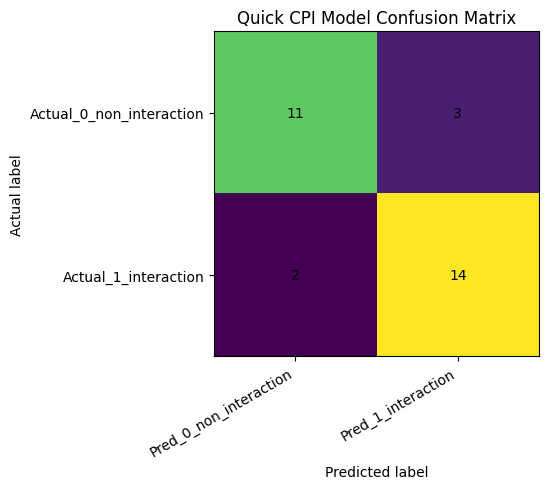

In [ ]:
# ============================================================
# Cell 13D: Display quick evaluation outputs
# ============================================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

eval_dir = REPO_ROOT / "output" / "evaluation"

metrics_file = eval_dir / "quick_evaluation_metrics.csv"
cm_file = eval_dir / "quick_confusion_matrix.csv"
report_file = eval_dir / "quick_classification_report.csv"
pred_file = eval_dir / "quick_test_predictions.csv"

print("Evaluation output directory:", eval_dir)

metrics_df = pd.read_csv(metrics_file)
cm_df = pd.read_csv(cm_file, index_col=0)
report_df = pd.read_csv(report_file, index_col=0)
pred_df = pd.read_csv(pred_file)

print("\nMetrics:")
display(metrics_df)

print("\nConfusion matrix:")
display(cm_df)

print("\nClassification report:")
display(report_df)

print("\nPrediction preview:")
display(pred_df.head())

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_df.values)

ax.set_xticks(range(len(cm_df.columns)))
ax.set_yticks(range(len(cm_df.index)))
ax.set_xticklabels(cm_df.columns, rotation=30, ha="right")
ax.set_yticklabels(cm_df.index)

for i in range(cm_df.shape[0]):
    for j in range(cm_df.shape[1]):
        ax.text(j, i, int(cm_df.values[i, j]), ha="center", va="center")

ax.set_title("Quick CPI Model Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("Actual label")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Cell 14: Generate CPI / GNN exploration summary report
# ============================================================

from pathlib import Path
from datetime import datetime
import pandas as pd
import torch

eval_dir = REPO_ROOT / "output" / "evaluation"
result_dir = REPO_ROOT / "output" / "result"
model_dir = REPO_ROOT / "output" / "model"

metrics_file = eval_dir / "quick_evaluation_metrics.csv"
cm_file = eval_dir / "quick_confusion_matrix.csv"
report_file = eval_dir / "quick_classification_report.csv"

metrics_df = pd.read_csv(metrics_file) if metrics_file.exists() else pd.DataFrame()
cm_df = pd.read_csv(cm_file, index_col=0) if cm_file.exists() else pd.DataFrame()
report_df = pd.read_csv(report_file, index_col=0) if report_file.exists() else pd.DataFrame()

quick_auc_files = sorted(result_dir.glob("AUCs--human_quick--quick*.txt"))
quick_model_files = sorted(model_dir.glob("human_quick--quick*"))

summary_lines = []

summary_lines.append("# CPI / GNN Exploration Summary")
summary_lines.append("")
summary_lines.append(f"Run time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
summary_lines.append("")

summary_lines.append("## 1. Purpose")
summary_lines.append("")
summary_lines.append(
    "This notebook explores the CPI_prediction repository suggested for compound-protein interaction prediction. "
    "The purpose is to test whether the repository can be reproduced in Colab, whether GPU can be used, "
    "and whether the CPI model can generate machine learning outputs that may later be integrated with the MRDRP dashboard."
)
summary_lines.append("")

summary_lines.append("## 2. Repository and model type")
summary_lines.append("")
summary_lines.append("- Repository: https://github.com/masashitsubaki/CPI_prediction")
summary_lines.append("- Model direction: compound-protein interaction prediction.")
summary_lines.append("- Compound input: SMILES converted into molecular graph features using RDKit.")
summary_lines.append("- Protein input: amino acid sequence represented using n-gram features.")
summary_lines.append("- Model structure: GNN-based compound encoder and CNN/attention-based protein encoder.")
summary_lines.append("- Important note: this repository mainly uses 2D molecular graph representation from SMILES, not a full 3D coordinate-based GNN.")
summary_lines.append("")

summary_lines.append("## 3. Environment")
summary_lines.append("")
summary_lines.append(f"- PyTorch version: {torch.__version__}")
summary_lines.append(f"- CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    summary_lines.append(f"- GPU: {torch.cuda.get_device_name(0)}")
summary_lines.append("")

summary_lines.append("## 4. Compatibility patches applied")
summary_lines.append("")
summary_lines.append(
    "- RDKit installation was adapted for the current Colab Python environment by using the modern `rdkit` package instead of `rdkit-pypi`."
)
summary_lines.append(
    "- `preprocess_data.py` was patched to save heterogeneous molecular graph objects as NumPy object arrays with `allow_pickle=True`."
)
summary_lines.append(
    "- `run_training.py` was patched to load object arrays using `np.load(..., allow_pickle=True)`."
)
summary_lines.append(
    "- A quick subset dataset was created to avoid running the original full 100-iteration training script during initial exploration."
)
summary_lines.append("")

summary_lines.append("## 5. Quick training setting")
summary_lines.append("")
summary_lines.append("- Dataset: human_quick")
summary_lines.append("- Quick subset size: 300 CPI samples")
summary_lines.append("- Training mode: smoke test / feasibility run")
summary_lines.append("- Iterations: 3 setting in shell script, resulting in 2 training epochs")
summary_lines.append("- Purpose: verify that the repo can preprocess data, use GPU, train a model, and produce outputs.")
summary_lines.append("")

if len(quick_auc_files) > 0:
    latest_auc_file = quick_auc_files[-1]
    auc_df = pd.read_csv(latest_auc_file, sep="\t")
    summary_lines.append("## 6. Quick training AUC output")
    summary_lines.append("")
    summary_lines.append(f"- AUC file: `{latest_auc_file}`")
    summary_lines.append("")
    summary_lines.append(auc_df.to_markdown(index=False))
    summary_lines.append("")

if len(metrics_df) > 0:
    summary_lines.append("## 7. Quick evaluation metrics")
    summary_lines.append("")
    summary_lines.append(metrics_df.to_markdown(index=False))
    summary_lines.append("")

if len(cm_df) > 0:
    summary_lines.append("## 8. Confusion matrix")
    summary_lines.append("")
    summary_lines.append(cm_df.to_markdown())
    summary_lines.append("")

if len(report_df) > 0:
    summary_lines.append("## 9. Classification report")
    summary_lines.append("")
    summary_lines.append(report_df.to_markdown())
    summary_lines.append("")

summary_lines.append("## 10. Interpretation")
summary_lines.append("")
summary_lines.append(
    "The quick CPI model run successfully used GPU and generated AUC, precision, recall, confusion matrix, and classification report outputs. "
    "This confirms that the CPI_prediction repository can be adapted and executed in the current Colab environment. "
    "However, the current quick result should not be treated as a final benchmark because it uses only a small subset and very few training epochs."
)
summary_lines.append("")

summary_lines.append("## 11. Integration with MRDRP")
summary_lines.append("")
summary_lines.append(
    "The MR pipeline provides genetic evidence for exposure-outcome relationships, while the CPI module can provide molecular interaction prediction between Artesunate and candidate protein targets. "
    "The next development step is to prepare Artesunate SMILES and candidate protein sequences, then evaluate whether the trained or adapted CPI model can score Artesunate-protein interactions."
)
summary_lines.append("")

summary_lines.append("## 12. Next technical steps")
summary_lines.append("")
summary_lines.append("- Retrieve and verify Artesunate SMILES from a reliable chemical database.")
summary_lines.append("- Create a candidate protein target list relevant to Artesunate, SHBG/GDF15-related biology, or endometrial cancer pathways.")
summary_lines.append("- Prepare protein sequences in FASTA / amino acid sequence format.")
summary_lines.append("- Build a prediction input table with compound SMILES and protein sequences.")
summary_lines.append("- Decide whether to use the current CPI model as a feasibility module or extend toward a true 3D GNN using molecular conformers and 3D coordinates.")
summary_lines.append("- Add a CPI / Molecular Interaction Prediction page to the dashboard after prediction outputs are available.")

summary_text = "\n".join(summary_lines)

summary_path = OUTPUT_ROOT / "cpi_gnn_exploration_summary.md"
summary_path.write_text(summary_text, encoding="utf-8")

print("CPI exploration summary saved to:")
print(summary_path)
print("\nPreview:")
print(summary_text[:5000])

CPI exploration summary saved to:
/content/drive/MyDrive/UM_WQF7023/CPI_3D_GNN_Exploration/outputs/cpi_gnn_exploration_summary.md

Preview:
# CPI / GNN Exploration Summary

Run time: 2026-06-01 16:17:42

## 1. Purpose

This notebook explores the CPI_prediction repository suggested for compound-protein interaction prediction. The purpose is to test whether the repository can be reproduced in Colab, whether GPU can be used, and whether the CPI model can generate machine learning outputs that may later be integrated with the MRDRP dashboard.

## 2. Repository and model type

- Repository: https://github.com/masashitsubaki/CPI_prediction
- Model direction: compound-protein interaction prediction.
- Compound input: SMILES converted into molecular graph features using RDKit.
- Protein input: amino acid sequence represented using n-gram features.
- Model structure: GNN-based compound encoder and CNN/attention-based protein encoder.
- Important note: this repository mainly uses 2D molecular gr

In [ ]:
# ============================================================
# Cell 15: Retrieve Artesunate SMILES from PubChem - final robust version
# ============================================================

import requests
import pandas as pd
from pathlib import Path
from rdkit import Chem
from rdkit.Chem import Descriptors

compound_name = "Artesunate"

# ------------------------------------------------------------
# Step 1: Get CID from PubChem by compound name
# ------------------------------------------------------------

cid_url = (
    "https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/"
    f"{compound_name}/cids/JSON"
)

print("Requesting PubChem CID for:", compound_name)
print(cid_url)

cid_response = requests.get(cid_url, timeout=30)

if cid_response.status_code != 200:
    raise RuntimeError(
        f"PubChem CID request failed. Status code: {cid_response.status_code}\n"
        f"{cid_response.text[:500]}"
    )

cid_data = cid_response.json()
cid_list = cid_data.get("IdentifierList", {}).get("CID", [])

if len(cid_list) == 0:
    raise ValueError("No PubChem CID found for Artesunate.")

cid = cid_list[0]
print("Selected PubChem CID:", cid)

# ------------------------------------------------------------
# Step 2: Retrieve compound properties by CID
# ------------------------------------------------------------

property_url = (
    "https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/"
    f"{cid}/property/CanonicalSMILES,IsomericSMILES,SMILES,ConnectivitySMILES,"
    "MolecularFormula,MolecularWeight,IUPACName/JSON"
)

print("\nRequesting PubChem properties:")
print(property_url)

property_response = requests.get(property_url, timeout=30)

if property_response.status_code != 200:
    raise RuntimeError(
        f"PubChem property request failed. Status code: {property_response.status_code}\n"
        f"{property_response.text[:500]}"
    )

property_data = property_response.json()
props = property_data.get("PropertyTable", {}).get("Properties", [{}])[0]

print("\nReturned PubChem property keys:")
print(list(props.keys()))

# ------------------------------------------------------------
# Step 3: Select a usable SMILES field
# ------------------------------------------------------------

smiles_candidates = {
    "CanonicalSMILES": props.get("CanonicalSMILES"),
    "IsomericSMILES": props.get("IsomericSMILES"),
    "SMILES": props.get("SMILES"),
    "ConnectivitySMILES": props.get("ConnectivitySMILES"),
}

selected_smiles = None
selected_smiles_type = None

for field_name, value in smiles_candidates.items():
    if value is not None and str(value).strip() != "":
        candidate = str(value).strip()
        mol_test = Chem.MolFromSmiles(candidate)
        if mol_test is not None:
            selected_smiles = candidate
            selected_smiles_type = field_name
            break

if selected_smiles is None:
    print("\nFull PubChem props returned:")
    print(props)
    raise ValueError("No usable RDKit-valid SMILES field was returned by PubChem for Artesunate.")

print("\nSelected SMILES type:", selected_smiles_type)
print("Selected SMILES:", selected_smiles)

# ------------------------------------------------------------
# Step 4: Validate SMILES with RDKit
# ------------------------------------------------------------

mol = Chem.MolFromSmiles(selected_smiles)

artesunate_record = {
    "compound_name": compound_name,
    "CID": props.get("CID", cid),
    "CanonicalSMILES": props.get("CanonicalSMILES"),
    "IsomericSMILES": props.get("IsomericSMILES"),
    "SMILES": props.get("SMILES"),
    "ConnectivitySMILES": props.get("ConnectivitySMILES"),
    "selected_smiles_type": selected_smiles_type,
    "selected_smiles": selected_smiles,
    "MolecularFormula": props.get("MolecularFormula"),
    "MolecularWeight": props.get("MolecularWeight"),
    "IUPACName": props.get("IUPACName"),
    "rdkit_valid": mol is not None,
}

if mol is not None:
    artesunate_record["rdkit_num_atoms"] = mol.GetNumAtoms()
    artesunate_record["rdkit_mol_weight"] = Descriptors.MolWt(mol)
else:
    artesunate_record["rdkit_num_atoms"] = None
    artesunate_record["rdkit_mol_weight"] = None

artesunate_df = pd.DataFrame([artesunate_record])

artesunate_file = OUTPUT_ROOT / "artesunate_smiles_pubchem.csv"
artesunate_df.to_csv(artesunate_file, index=False)

display(artesunate_df)

print("\nSaved to:", artesunate_file)

Requesting PubChem CID for: Artesunate
https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/Artesunate/cids/JSON
Selected PubChem CID: 6917864

Requesting PubChem properties:
https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/6917864/property/CanonicalSMILES,IsomericSMILES,SMILES,ConnectivitySMILES,MolecularFormula,MolecularWeight,IUPACName/JSON

Returned PubChem property keys:
['CID', 'MolecularFormula', 'MolecularWeight', 'SMILES', 'ConnectivitySMILES', 'IUPACName']

Selected SMILES type: SMILES
Selected SMILES: C[C@@H]1CC[C@H]2[C@H]([C@@H](O[C@H]3[C@@]24[C@H]1CC[C@](O3)(OO4)C)OC(=O)CCC(=O)O)C


,compound_name,CID,CanonicalSMILES,IsomericSMILES,SMILES,ConnectivitySMILES,selected_smiles_type,selected_smiles,MolecularFormula,MolecularWeight,IUPACName,rdkit_valid,rdkit_num_atoms,rdkit_mol_weight
0,Artesunate,6917864,None,None,C[C@@H]1CC[C@H]2[C@H]([C@@H](O[C@H]3[C@@]24[C@...,CC1CCC2C(C(OC3C24C1CCC(O3)(OO4)C)OC(=O)CCC(=O)O)C,SMILES,C[C@@H]1CC[C@H]2[C@H]([C@@H](O[C@H]3[C@@]24[C@...,C19H28O8,384.4,"4-oxo-4-[[(1R,4S,5R,8S,9R,10S,12R,13R)-1,5,9-t...",True,27,384.425



Saved to: /content/drive/MyDrive/UM_WQF7023/CPI_3D_GNN_Exploration/outputs/artesunate_smiles_pubchem.csv


In [ ]:
# ============================================================
# Cell 16: Create candidate protein target template
# ============================================================

candidate_targets = [
    {
        "target_name": "SHBG",
        "gene_symbol": "SHBG",
        "uniprot_id": "",
        "protein_sequence": "",
        "selection_reason": "MR exposure candidate; related to sex hormone-binding globulin biology."
    },
    {
        "target_name": "GDF15",
        "gene_symbol": "GDF15",
        "uniprot_id": "",
        "protein_sequence": "",
        "selection_reason": "MR exposure candidate; growth differentiation factor 15."
    },
    {
        "target_name": "IGF1",
        "gene_symbol": "IGF1",
        "uniprot_id": "",
        "protein_sequence": "",
        "selection_reason": "MR exposure candidate; insulin-like growth factor 1."
    },
    {
        "target_name": "ADIPOQ",
        "gene_symbol": "ADIPOQ",
        "uniprot_id": "",
        "protein_sequence": "",
        "selection_reason": "MR exposure candidate; adiponectin-related biology."
    },
]

target_template_df = pd.DataFrame(candidate_targets)

target_template_file = OUTPUT_ROOT / "candidate_protein_target_template.csv"
target_template_df.to_csv(target_template_file, index=False)

display(target_template_df)

print("Candidate target template saved to:")
print(target_template_file)

,target_name,gene_symbol,uniprot_id,protein_sequence,selection_reason
0,SHBG,SHBG,,,MR exposure candidate; related to sex hormone-...
1,GDF15,GDF15,,,MR exposure candidate; growth differentiation ...
2,IGF1,IGF1,,,MR exposure candidate; insulin-like growth fac...
3,ADIPOQ,ADIPOQ,,,MR exposure candidate; adiponectin-related bio...


Candidate target template saved to:
/content/drive/MyDrive/UM_WQF7023/CPI_3D_GNN_Exploration/outputs/candidate_protein_target_template.csv


In [ ]:
# ============================================================
# Cell 17: Create dashboard-ready CPI exploration status table
# ============================================================

from pathlib import Path
import pandas as pd

status_records = []

files_to_check = {
    "CPI exploration summary": OUTPUT_ROOT / "cpi_gnn_exploration_summary.md",
    "Quick training log": OUTPUT_ROOT / "run_training_quick_log.txt",
    "Quick evaluation log": OUTPUT_ROOT / "quick_evaluation_log.txt",
    "Quick evaluation metrics": REPO_ROOT / "output" / "evaluation" / "quick_evaluation_metrics.csv",
    "Quick confusion matrix": REPO_ROOT / "output" / "evaluation" / "quick_confusion_matrix.csv",
    "Quick classification report": REPO_ROOT / "output" / "evaluation" / "quick_classification_report.csv",
    "Quick test predictions": REPO_ROOT / "output" / "evaluation" / "quick_test_predictions.csv",
    "Artesunate SMILES": OUTPUT_ROOT / "artesunate_smiles_pubchem.csv",
    "Candidate protein target template": OUTPUT_ROOT / "candidate_protein_target_template.csv",
}

for name, path in files_to_check.items():
    path = Path(path)
    status_records.append({
        "output_name": name,
        "file_name": path.name,
        "exists": path.exists(),
        "size_KB": round(path.stat().st_size / 1024, 2) if path.exists() else 0,
        "path": str(path),
    })

cpi_status_df = pd.DataFrame(status_records)

cpi_status_file = OUTPUT_ROOT / "cpi_exploration_output_status.csv"
cpi_status_df.to_csv(cpi_status_file, index=False)

display(cpi_status_df)

print("CPI status table saved to:")
print(cpi_status_file)

,output_name,file_name,exists,size_KB,path
0,CPI exploration summary,cpi_gnn_exploration_summary.md,True,5.16,/content/drive/MyDrive/UM_WQF7023/CPI_3D_GNN_E...
1,Quick training log,run_training_quick_log.txt,True,0.27,/content/drive/MyDrive/UM_WQF7023/CPI_3D_GNN_E...
2,Quick evaluation log,quick_evaluation_log.txt,True,1.67,/content/drive/MyDrive/UM_WQF7023/CPI_3D_GNN_E...
3,Quick evaluation metrics,quick_evaluation_metrics.csv,True,0.17,/content/drive/MyDrive/UM_WQF7023/CPI_3D_GNN_E...
4,Quick confusion matrix,quick_confusion_matrix.csv,True,0.10,/content/drive/MyDrive/UM_WQF7023/CPI_3D_GNN_E...
5,Quick classification report,quick_classification_report.csv,True,0.40,/content/drive/MyDrive/UM_WQF7023/CPI_3D_GNN_E...
6,Quick test predictions,quick_test_predictions.csv,True,0.71,/content/drive/MyDrive/UM_WQF7023/CPI_3D_GNN_E...
7,Artesunate SMILES,artesunate_smiles_pubchem.csv,True,0.61,/content/drive/MyDrive/UM_WQF7023/CPI_3D_GNN_E...
8,Candidate protein target template,candidate_protein_target_template.csv,True,0.35,/content/drive/MyDrive/UM_WQF7023/CPI_3D_GNN_E...


CPI status table saved to:
/content/drive/MyDrive/UM_WQF7023/CPI_3D_GNN_Exploration/outputs/cpi_exploration_output_status.csv
